## Đọc dữ liệu





In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import seaborn as sns

Read data file


In [5]:
train_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/validation.csv")
test_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (11426, 5)
Validation shape: (1583, 5)
Test shape: (3166, 5)


Đặt tên và gộp file

In [14]:
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Tổng số dòng sau khi gộp:", df.shape[0])
print("Tổng số cột gộp:", df.shape[1])
df.head(20)

Tổng số dòng sau khi gộp: 16175
Tổng số cột gộp: 6


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,slide giáo trình đầy đủ .,2,1,positive,training_program,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,positive,lecturer,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,negative,training_program,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,negative,lecturer,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,positive,lecturer,train
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",2,0,positive,lecturer,train
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",1,3,neutral,others,train
7,"thời lượng học quá dài , không đảm bảo tiếp th...",0,1,negative,training_program,train
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",0,1,negative,training_program,train
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,0,1,negative,training_program,train


Xem tổng quan

In [ ]:
print("TRAIN")
display(train_df.head())

print("VALIDATION")
display(val_df.head())

print("TEST")
display(test_df.head())

TRAIN


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,slide giáo trình đầy đủ .,2,1,positive,training_program,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,positive,lecturer,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,negative,training_program,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,negative,lecturer,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,positive,lecturer,train


VALIDATION


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,giáo trình chưa cụ thể .,0,1,negative,training_program,validation
1,giảng buồn ngủ .,0,0,negative,lecturer,validation
2,"giáo viên vui tính , tận tâm .",2,0,positive,lecturer,validation
3,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,0,negative,lecturer,validation
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,0,negative,lecturer,validation


TEST


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,nói tiếng anh lưu loát .,2,0,positive,lecturer,test
1,giáo viên rất vui tính .,2,0,positive,lecturer,test
2,cô max có tâm .,2,0,positive,lecturer,test
3,"giảng bài thu hút , dí dỏm .",2,0,positive,lecturer,test
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0,negative,lecturer,test


Kiểm tra dữ liệu thiếu, trùng lặp


In [ ]:
print("===== GIÁ TRỊ THIẾU =====")
print(df.isnull().sum())

print("\n===== DÒNG BỊ TRÙNG =====")
print("Số dòng trùng hoàn toàn:", df.duplicated().sum())

print("\n===== CÂU BỊ TRÙNG =====")
print("Số câu bị trùng:", df["sentence"].duplicated().sum())

===== GIÁ TRỊ THIẾU =====
sentence           0
sentiment          0
topic              0
sentiment_label    0
topic_label        0
split              0
dtype: int64

===== DÒNG BỊ TRÙNG =====
Số dòng trùng hoàn toàn: 0

===== CÂU BỊ TRÙNG =====
Số câu bị trùng: 1


In [ ]:
# Xử lý data
df.drop_duplicates(subset=['sentence'], inplace=True)

print("Số câu bị trùng sau khi xử lý:", df["sentence"].duplicated().sum())
print("Tổng số dòng sau khi xử lý trùng lặp:", df.shape[0])

Số câu bị trùng sau khi xử lý: 0
Tổng số dòng sau khi xử lý trùng lặp: 16174


# Thống kê mô tả

In [ ]:
df["split"].value_counts()

,count
split,
train,11425
test,3166
validation,1583


In [ ]:
#Phân bố sentiment

df["sentiment_label"].value_counts()

,count
sentiment_label,
positive,8038
negative,7438
neutral,698


In [13]:
# Phân bố topic
df["topic_label"].value_counts()

,count
topic_label,
lecturer,11607
training_program,3040
others,816
facility,712


In [17]:
#Đặc trưng độ dài câu
df["char_count"] = df["sentence"].astype(str).apply(len)
df["word_count"] = df["sentence"].astype(str).apply(lambda x: len(x.split()))
display(df[["sentence", "char_count", "word_count"]].head())

,sentence,char_count,word_count
0,slide giáo trình đầy đủ .,25,6
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",46,11
2,đi học đầy đủ full điểm chuyên cần .,36,9
3,chưa áp dụng công nghệ thông tin và các thiết ...,76,18
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",59,15


In [18]:
# Thống kê độ dài câu
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,16175.000000,16175.000000
mean,58.769768,14.229181
std,43.264994,10.103769
min,4.000000,2.000000
25%,31.000000,8.000000
50%,46.000000,11.000000
75%,73.000000,17.000000
max,718.000000,161.000000


Phân bố topic theo từng split

In [21]:
#Độ dài tb câu sentiment

df.groupby("sentiment_label")[["word_count", "char_count"]].mean().round(3)

,word_count,char_count
sentiment_label,,
negative,16.892,70.544
neutral,9.821,39.189
positive,12.148,49.574


In [23]:
#Độ dài câu trung bình của topic

df.groupby("topic_label")[["word_count", "char_count"]].mean().round(2)

,word_count,char_count
topic_label,,
facility,16.97,71.35
lecturer,13.70,56.56
others,9.95,39.22
training_program,16.76,69.50


In [24]:
# Làm sạch văn bản đơn giản

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

Hàm này dùng để:

chuyển chữ thường

bỏ dấu câu

xóa khoảng trắng dư

để phục vụ bước đếm từ xuất hiện nhiều.

Đếm từ xuất hiện nhiều nhất

In [25]:
all_words = " ".join(df["sentence"].apply(clean_text)).split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(10), columns=["word", "frequency"])
display(top_words)

,word,frequency
0,viên,6700
1,giảng,5239
2,dạy,4523
3,thầy,4409
4,sinh,4278
5,học,4114
6,bài,3309
7,tình,3211
8,không,3096
9,và,2904


In [ ]:
for label in df["sentiment_label"].unique():
    print(f"\n===== {label.upper()} =====")
    display(df[df["sentiment_label"] == label][["sentence", "topic_label"]].head(5))


===== POSITIVE =====


,sentence,topic_label
0,slide giáo trình đầy đủ .,training_program
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",lecturer
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",lecturer
10,thầy rất tận tình và đi dạy rất đúng giờ .,lecturer



===== NEGATIVE =====


,sentence,topic_label
2,đi học đầy đủ full điểm chuyên cần .,training_program
3,chưa áp dụng công nghệ thông tin và các thiết ...,lecturer
7,"thời lượng học quá dài , không đảm bảo tiếp th...",training_program
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",training_program
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,training_program



===== NEUTRAL =====


,sentence,topic_label
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",others
12,đang dạy thầy wzjwz208 đi qua nước ngoài giữa ...,lecturer
55,tạo ra sự cạnh tranh trong mỗi buổi thực hành .,lecturer
70,ôn tập đúng theo thầy nhưng không biết cuối kỳ...,training_program
116,bài tập trên lớp .,training_program


Cell này cho xem ví dụ thực tế của từng nhãn cảm xúc để hiểu dữ liệu rõ hơn.

In [ ]:
for label in df["topic_label"].unique():
    print(f"\n===== {label.upper()} =====")
    display(df[df["topic_label"] == label][["sentence", "sentiment_label"]].head(5))


===== TRAINING_PROGRAM =====


,sentence,sentiment_label
0,slide giáo trình đầy đủ .,positive
2,đi học đầy đủ full điểm chuyên cần .,negative
7,"thời lượng học quá dài , không đảm bảo tiếp th...",negative
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",negative
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,negative



===== LECTURER =====


,sentence,sentiment_label
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive
3,chưa áp dụng công nghệ thông tin và các thiết ...,negative
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",positive
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",positive
10,thầy rất tận tình và đi dạy rất đúng giờ .,positive



===== OTHERS =====


,sentence,sentiment_label
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",neutral
11,dễ bị áp lực .,negative
15,hài lòng về tất cả .,positive
36,"chúc các thầy cô , anh chị làm việc vui vẻ !",positive
102,cần có sự tương tác giữa giảng viên và sinh vi...,negative



===== FACILITY =====


,sentence,sentiment_label
57,"cần nâng cấp hệ thống wifi , vì khi vào phòng ...",negative
75,"cần có một phòng máy tốt hơn , hiện đại hơn .",negative
93,cải thiện lại cơ sở vật chất máy chiếu trong p...,negative
128,mong ban thiết bị sớm khắc phục ạ !,negative
143,theo em thì nên thi phòng máy nào có visual 20...,negative


In [10]:
# Kiểm tra xem có câu nào ở tập Test/Val đã xuất hiện ở tập Train không
train_sentences = set(df[df['split'] == 'train']['sentence'])
val_sentences = set(df[df['split'] == 'val']['sentence'])
test_sentences = set(df[df['split'] == 'test']['sentence'])

leakage_val = val_sentences.intersection(train_sentences)
leakage_test = test_sentences.intersection(train_sentences)


print(f"Số câu trùng lặp giữa Train và Val: {len(leakage_val)}")
print(f"Số câu trùng lặp giữa Train và Test: {len(leakage_test)}")

# Nếu có trùng, hãy loại bỏ khỏi tập Train
# df = df[~((df['split'] == 'train') & (df['sentence'].isin(leakage_val | leakage_test)))]

Số câu trùng lặp giữa Train và Val: 0
Số câu trùng lặp giữa Train và Test: 0


In [ ]:
# Kiểm tra các câu quá ngắn (nhiễu)
short_feedback = df[df['sentence'].str.len() < 5]
print(f"Số lượng feedback cực ngắn (< 5 ký tự): {len(short_feedback)}")
print(short_feedback['sentence'].head())

# Nếu quá ngắn và không mang nghĩa, nên cân nhắc xóa bỏ để tránh model bị 'confused'

Số lượng feedback cực ngắn (< 5 ký tự): 4
3319     tệ .
9895     dễ .
12050    có .
13050    ổn .
Name: sentence, dtype: object


# Trực quan hóa

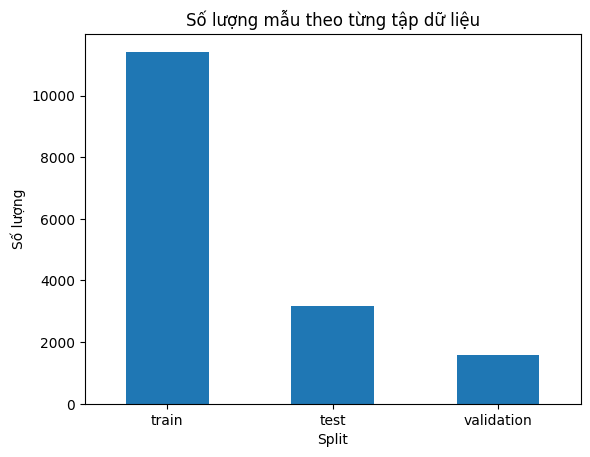

In [ ]:
df["split"].value_counts().plot(kind="bar")
plt.title("Số lượng mẫu theo từng tập dữ liệu")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

topic_label,facility,lecturer,others,training_program
split,,,,
test,145,2290,159,572
train,497,8165,562,2201
validation,70,1151,95,267


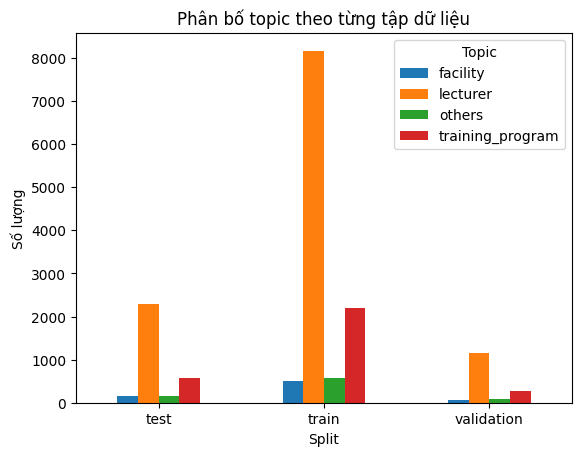

In [ ]:
topic_by_split = pd.crosstab(df["split"], df["topic_label"])
display(topic_by_split)

topic_by_split.plot(kind="bar")
plt.title("Phân bố topic theo từng tập dữ liệu")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.legend(title="Topic")
plt.show()

Phân bố số lượng sentiment:
sentiment_label  negative  neutral  positive
split                                       
test                 1409      167      1590
train                5325      458      5643
validation            705       73       805

Phân bố tỷ lệ phần trăm sentiment:
sentiment_label  negative  neutral  positive
split                                       
test                44.50     5.27     50.22
train               46.60     4.01     49.39
validation          44.54     4.61     50.85


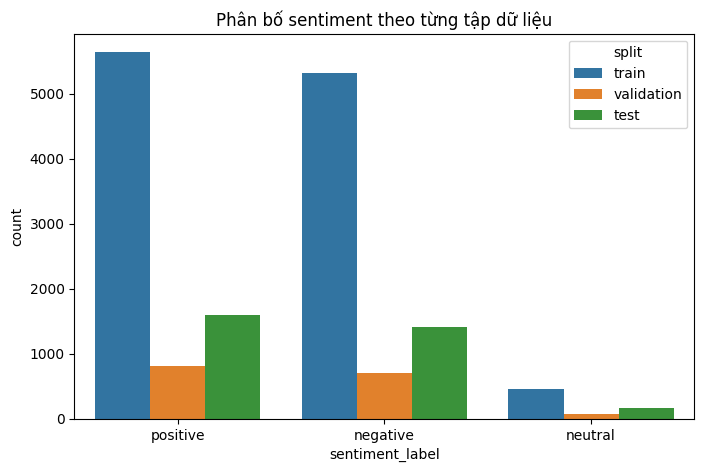

In [31]:

pivot_table = pd.crosstab(df["split"], df["sentiment_label"])
print("Phân bố số lượng sentiment:")
print(pivot_table)

# 2. Bảng phân bố tỷ lệ phần trăm sentiment theo từng split
pivot_percent = pd.crosstab(df["split"], df["sentiment_label"], normalize="index") * 100
print("\nPhân bố tỷ lệ phần trăm sentiment:")
print(pivot_percent.round(2))

# 3. Biểu đồ trực quan hóa
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sentiment_label", hue="split")
plt.title("Phân bố sentiment theo từng tập dữ liệu")
plt.show()

===== PHÂN BỐ TOPIC TOÀN BỘ DỮ LIỆU =====


,count
topic_label,
lecturer,11606
training_program,3040
others,816
facility,712


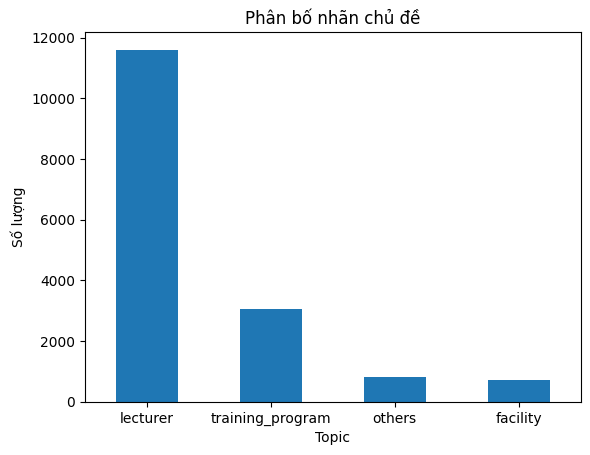

In [ ]:
print("===== PHÂN BỐ TOPIC TOÀN BỘ DỮ LIỆU =====")
display(df["topic_label"].value_counts())

df["topic_label"].value_counts().plot(kind="bar")
plt.title("Phân bố nhãn chủ đề")
plt.xlabel("Topic")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

,count
sentiment_label,
positive,8038
negative,7439
neutral,698


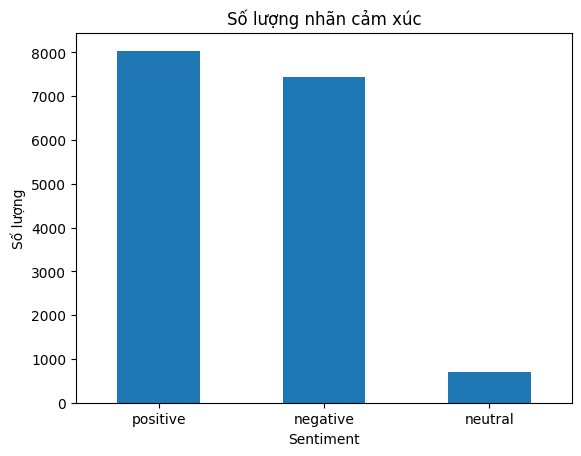

In [33]:
display(df["sentiment_label"].value_counts())

df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Số lượng nhãn cảm xúc")
plt.xlabel("Sentiment")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

sentiment_label,negative,neutral,positive
topic_label,,,
facility,681,13,18
lecturer,4104,292,7210
others,325,231,260
training_program,2328,162,550


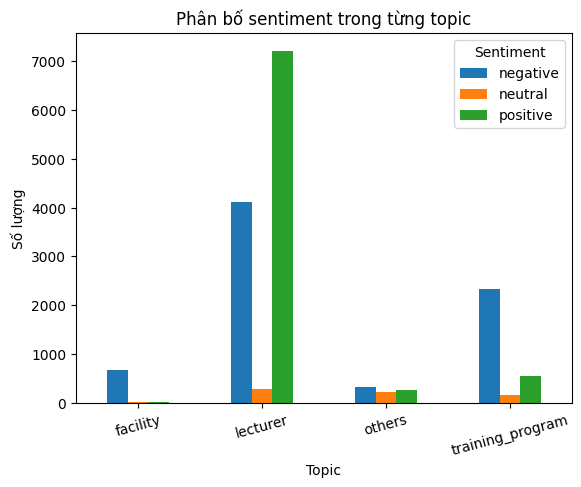

In [ ]:
cross_tab = pd.crosstab(df["topic_label"], df["sentiment_label"])
display(cross_tab)

cross_tab.plot(kind="bar")
plt.title("Phân bố sentiment trong từng topic")
plt.xlabel("Topic")
plt.ylabel("Số lượng")
plt.xticks(rotation=15)
plt.legend(title="Sentiment")
plt.show()

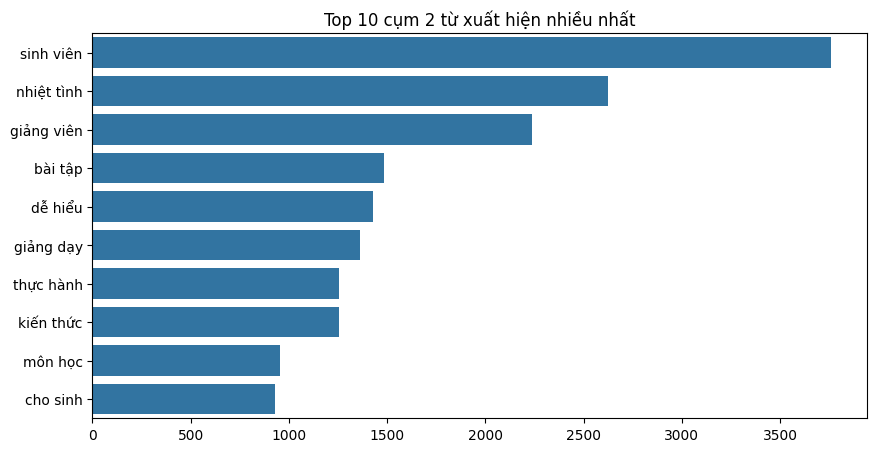

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# Xem 10 cụm 2 từ (bigrams) xuất hiện nhiều nhất
top_bigrams = get_top_ngram(df['sentence'], 2)
x, y = map(list, zip(*top_bigrams))
plt.figure(figsize=(10, 5))
sns.barplot(x=y, y=x)
plt.title('Top 10 cụm 2 từ xuất hiện nhiều nhất')
plt.show()

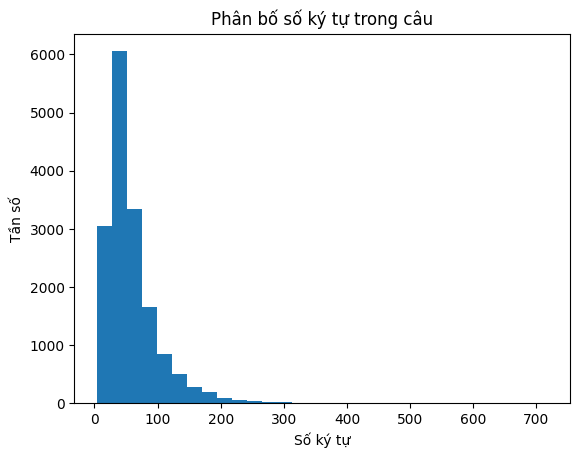

In [ ]:
#\Vẽ histogram số ký tự
plt.hist(df["char_count"], bins=30)
plt.title("Phân bố số ký tự trong câu")
plt.xlabel("Số ký tự")
plt.ylabel("Tần số")
plt.show()

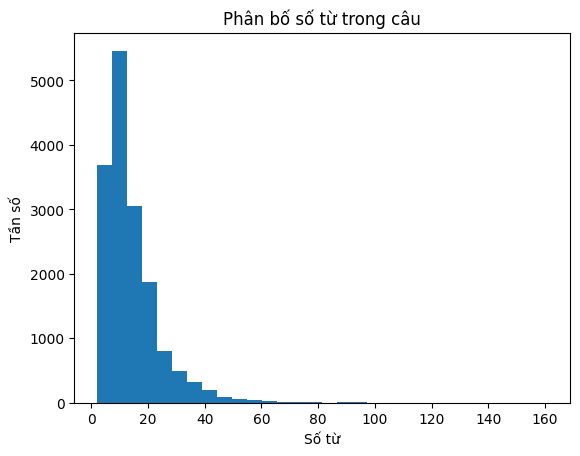

In [ ]:
#Vẽ histogram số từ


plt.hist(df["word_count"], bins=30)
plt.title("Phân bố số từ trong câu")
plt.xlabel("Số từ")
plt.ylabel("Tần số")
plt.show()

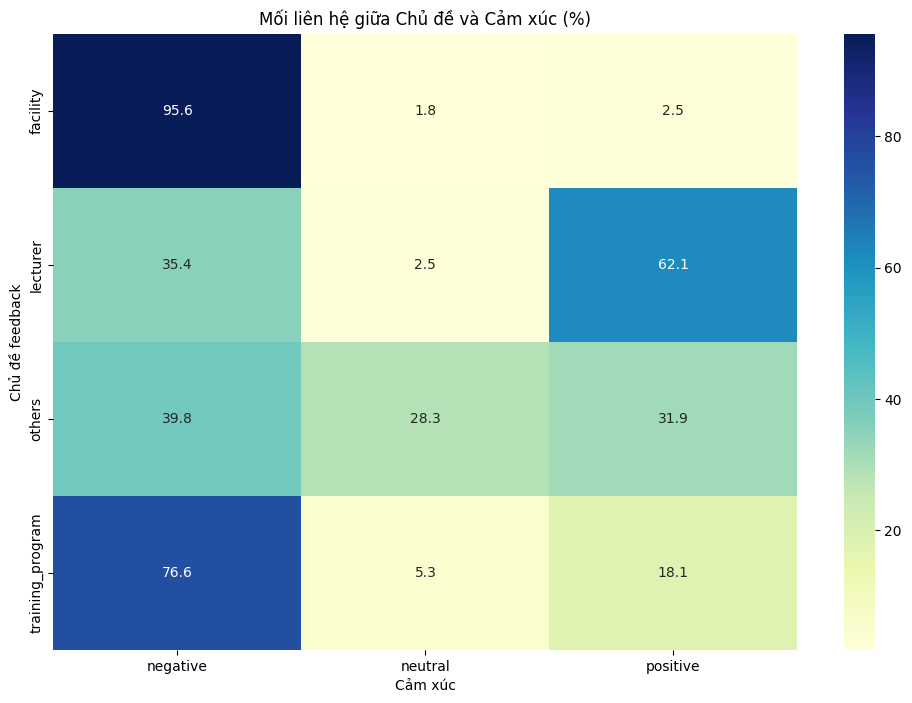

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo bảng chéo giữa Topic và Sentiment
topic_sentiment_dist = pd.crosstab(df['topic_label'], df['sentiment_label'], normalize='index') * 100

# Vẽ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(topic_sentiment_dist, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Mối liên hệ giữa Chủ đề và Cảm xúc (%)')
plt.xlabel('Cảm xúc')
plt.ylabel('Chủ đề feedback')
plt.show()